<div style="text-align:center;">
  <b>Национальный исследовательский университет ИТМО</b><br>
  Факультет информационных технологий и программирования<br>
  Кафедра Компьютерных Технологий
</div>


---

# **Методы оптимизации**
### Лабораторная работа №3
### Метод стохастического градиентного спуска (SGD) и его модификации

<div style="text-align:right; font-size:12px">
Выполнили:<br>
Алфёров Кирилл М3232<br>
Салов Егор М3232
</div>





### Информация о датасете

Датасет содержит 9358 записей с почасовыми усреднёнными откликами от массива из 5 химических сенсоров на основе металлических оксидов, встроенных в устройство химического мониторинга качества воздуха. Устройство было размещено на улице в зоне с высоким уровнем загрязнения, на уровне дороги, в одном из городов Италии. Данные собирались с марта 2004 по февраль 2005 года (в течение одного года), что делает этот набор данных одним из самых продолжительных по длительности свободно доступных полевых наблюдений с использованием химических сенсоров.

Эталонные (ground truth) данные о почасовых усреднённых концентрациях угарного газа (CO), неметановых углеводородов, бензола, суммарных оксидов азота (NOx) и диоксида азота (NO₂) были получены с помощью сертифицированного анализатора, установленного рядом.

В данных присутствуют признаки перекрёстной чувствительности сенсоров, а также концептуального и сенсорного дрейфа, что описано в статье De Vito и др., Sens. and Act. B, Vol. 129, №2, 2008 (необходима ссылка на источник). Эти эффекты могут снижать точность оценки концентраций загрязняющих веществ по данным сенсоров. Пропущенные значения помечены как -200.

### Читаем датасет

In [ ]:
import pandas

dataset = pandas.read_csv("dataset/AirQualityUCI.csv", sep=';', decimal=',')
dataset

### Вычислим корреляцию параметров попарно

In [ ]:
dataset.corr(numeric_only=True)

### Что берём?


Для нашей регрессионной модели мы решили предсказывать именно **C6H6(GT)** (концентрацию бензола, мкг/м³). Вот почему:

1. **Очень сильная линейная связь**
   - С абсолютной влажностью (AH): *r* ≈ 0.985
   - С температурой воздуха (T): *r* ≈ 0.971
   - С относительной влажностью (RH): *r* ≈ 0.925

   Когда |*r*| > 0.9, простая линейная модель уже способна выдавать точные и стабильные предсказания.

2. **Минимум избыточности среди признаков**
   Мы исключили сенсоры, которые почти полностью дублировали друг друга (корреляция > 0.9 между ними). В результате в качестве входных факторов остались только самые информативные переменные без сильной взаимозависимости


Итак, зависимая переменная **y = C6H6(GT)**, независимые переменные **x = AH (|r| = 0.985), PT08.S1(CO) (|r| = 0.853), PT08.S3(NOx) (|r| = 0.512)** (а также у датчиков PT08.S1(CO) и PT08.S3(NOx) слабая корреляция |r| = 0.087, что снижает мультиколлинеарность)




## PyTorch

In [ ]:
import torch
import pyTorch.Torch as Torch
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Загрузка и подготовка данных
X, y = load_diabetes(return_X_y=True)

# Масштабирование (важно для стабильного градиентного спуска)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Делим на train/test
x_tr, x_te, y_tr, y_te = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Перевод в torch.FloatTensor
xtr_t = torch.FloatTensor(x_tr)
xte_t = torch.FloatTensor(x_te)
ytr_t = torch.FloatTensor(y_tr).reshape(-1, 1)
yte_t = torch.FloatTensor(y_te).reshape(-1, 1)

learning_rates = {
    "SGD": 1e-2,
    "SGD+Momentum": 1e-2,
    "SGD+Nesterov": 1e-2,
    "Adagrad": 1e-2,
    "RMSprop": 1e-2,
    "Adam": 1e-2,
}

optimisers = list(learning_rates.keys())

results = []
for name in optimisers:
    res = Torch.train_torch(
        opt_name=name,
        xtr=xtr_t,
        ytr=ytr_t,
        xte=xte_t,
        yte=yte_t,
        epochs=50,
        batch_size=32,
        lr_dict=learning_rates
    )
    results.append(res)
    print(f"{name: <14} | MSE: {res['mse']:.4f} | Time: {res['time']:.2f}s | Mem: {res['memory']:.1f}MB")


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ваши результаты в виде словаря
results = [
    {"optimizer": "SGD", "mse": 0.4973, "time": 0.65},
    {"optimizer": "SGD+Momentum", "mse": 0.6735, "time": 0.48},
    {"optimizer": "SGD+Nesterov", "mse": 0.5176, "time": 0.46},
    {"optimizer": "Adagrad", "mse": 0.5436, "time": 0.87},
    {"optimizer": "RMSprop", "mse": 0.5236, "time": 1.36},
    {"optimizer": "Adam", "mse": 0.4821, "time": 1.43},
]

df = pd.DataFrame(results)

# График: MSE по оптимизатору
plt.figure(figsize=(10, 5))
plt.bar(df["optimizer"], df["mse"])
plt.ylabel("MSE (Mean Squared Error)")
plt.title("Сравнение оптимизаторов по MSE")
plt.grid(axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# График: Время по оптимизатору
plt.figure(figsize=(10, 5))
plt.bar(df["optimizer"], df["time"])
plt.ylabel("Время обучения (сек)")
plt.title("Сравнение оптимизаторов по времени обучения")
plt.grid(axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Keras

In [ ]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import kerasModel.KerasModel as Keras  # путь к вашему модулю, проверь

# Загрузка и масштабирование данных
X, y = load_diabetes(return_X_y=True)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Деление на train/test
x_tr, x_te, y_tr, y_te = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Перевод в tf.Tensor
xtr_tf = tf.convert_to_tensor(x_tr, dtype=tf.float32)
xte_tf = tf.convert_to_tensor(x_te, dtype=tf.float32)
ytr_tf = tf.convert_to_tensor(y_tr.reshape(-1, 1), dtype=tf.float32)
yte_tf = tf.convert_to_tensor(y_te.reshape(-1, 1), dtype=tf.float32)

# Гиперпараметры
learning_rates = {
    "SGD": 1e-2,
    "SGD+Momentum": 1e-2,
    "SGD+Nesterov": 1e-2,
    "Adagrad": 1e-2,
    "RMSprop": 1e-2,
    "Adam": 1e-2,
}

optimisers = list(learning_rates.keys())

# Запуск обучения
results = []
for name in optimisers:
    res = Keras.KerasLinearModel.train_keras(
        opt_name=name,
        xtr=xtr_tf,
        ytr=ytr_tf,
        xte=xte_tf,
        yte=yte_tf,
        lr_dict=learning_rates
    )
    results.append(res)
    print(f"{name: <14} | MSE: {res['mse']:.4f} | Time: {res['time']:.2f}s | Mem: {res['memory']:.1f}MB")


## Дополнительное задание №2
## Метод опорных векторов(SVM)

Была реализована модель бинарной классификации на основе **метода опорных векторов (Support Vector Machine, SVM)** с **линейным ядром**. Цель эксперимента — визуализировать процесс обучения модели, построение разделяющей гиперплоскости и выделение опорных векторов.

### Описание данных

Исходные данные включают 7 точек в двумерном пространстве:

- Класс **+1**: (1, 2), (2, 3), (3, 3)
- Класс **-1**: (2, 1), (3, 1), (3, 2), (3, 2.5)

### Параметры модели

Модель обучалась с использованием `SVC` из библиотеки `sklearn` с параметрами:

- `kernel='linear'` — используется линейное ядро (поиск прямой в 2D).
- `C=1000` — высокий коэффициент регуляризации, что требует строгого разделения классов.

После обучения из модели извлекаются параметры гиперплоскости:

- Вектор весов `w`
- Свободный член `b`

Уравнение гиперплоскости имеет вид:
w₁ * x₁ + w₂ * x₂ + b = 0



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Данные
X = np.array([[1, 2], [2, 3], [3, 3], [2, 1], [3, 1], [3, 2], [3, 2.5]])
y = np.array([1, 1, 1, -1, -1, -1, -1])

# Модель SVM с линейным ядром
svm_model = SVC(kernel='linear', C=1000)
svm_model.fit(X, y)

# Параметры гиперплоскости
w = svm_model.coef_[0]
b = svm_model.intercept_[0]

print(f'Гиперплоскость: {w[0]:.2f}*x₁ + {w[1]:.2f}*x₂ + {b:.2f} = 0')

fig, ax = plt.subplots(figsize=(8, 6))

# Отображаем точки двух классов
ax.scatter(X[y==1][:,0], X[y==1][:,1], color='blue', label='+1')
ax.scatter(X[y==-1][:,0], X[y==-1][:,1], color='red', label='-1')

# Строим разделяющую гиперплоскость
x_plot = np.linspace(0.5, 3.5, 100)
y_plot = -(w[0]/w[1])*x_plot - b/w[1]
ax.plot(x_plot, y_plot, 'k-', label='Гиперплоскость')

# Опорные векторы
ax.scatter(svm_model.support_vectors_[:,0], svm_model.support_vectors_[:,1],
           s=150, linewidth=1.5, facecolors='none', edgecolors='k', label='Опорные векторы')

ax.legend()
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('SVM Decision Boundary и Опорные Векторы')
plt.grid()
plt.show()




### Результаты

На итоговом графике показаны:

- Точки двух классов: синие — класс `+1`, красные — класс `-1`.
- **Гиперплоскость** — белая линия, разделяющая классы.
- **Опорные векторы** — точки, расположенные ближе всего к границе. Они обведены белыми кружками и играют ключевую роль в построении разделяющей прямой.

Метод SVM стремится не только разделить классы, но и **максимизировать отступ (margin)** между ними, что повышает устойчивость модели.

### Вывод

Метод SVM успешно построил разделяющую гиперплоскость для линейно разделимых данных. Визуализация иллюстрирует выбор границы и подчёркивает значимость опорных векторов при обучении модели.

В данных присутствуют признаки перекрёстной чувствительности сенсоров, а также концептуального и сенсорного дрейфа, что описано в статье De Vito и др., Sens. and Act. B, Vol. 129, №2, 2008 (необходима ссылка на источник). Эти эффекты могут снижать точность оценки концентраций загрязняющих веществ по данным сенсоров. Пропущенные значения помечены как -200.

### Читаем датасет

In [6]:
import pandas

import Model

dataset = pandas.read_csv("dataset/AirQualityUCI.csv", sep=';', decimal=',')
dataset

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Вычислим корреляцию параметров попарно

In [7]:
dataset.corr(numeric_only=True)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
CO(GT),1.000000,0.041411,0.128351,-0.031378,0.029926,0.526451,-0.089981,0.671127,-0.073724,0.080310,-0.068939,-0.048227,-0.045892,NaN,NaN
PT08.S1(CO),0.041411,1.000000,0.170007,0.852687,0.933102,0.277993,0.087019,0.154030,0.845149,0.892434,0.754844,0.745375,0.764903,NaN,NaN
NMHC(GT),0.128351,0.170007,1.000000,0.037323,0.110104,-0.004427,0.048821,0.103307,0.162680,0.101185,-0.000009,0.008284,0.012500,NaN,NaN
C6H6(GT),-0.031378,0.852687,0.037323,1.000000,0.767433,-0.001174,0.512193,-0.010992,0.774673,0.641334,0.971375,0.925062,0.984555,NaN,NaN
PT08.S2(NMHC),0.029926,0.933102,0.110104,0.767433,1.000000,0.331272,-0.073667,0.176488,0.874782,0.909905,0.669025,0.585803,0.646572,NaN,NaN
NOx(GT),0.526451,0.277993,-0.004427,-0.001174,0.331272,1.000000,-0.436084,0.817139,0.035546,0.461889,-0.138452,-0.053009,-0.095847,NaN,NaN
PT08.S3(NOx),-0.089981,0.087019,0.048821,0.512193,-0.073667,-0.436084,1.000000,-0.256232,0.122734,-0.208865,0.588111,0.573549,0.621618,NaN,NaN
NO2(GT),0.671127,0.154030,0.103307,-0.010992,0.176488,0.817139,-0.256232,1.000000,-0.022174,0.253439,-0.084104,-0.081305,-0.060440,NaN,NaN
PT08.S4(NO2),-0.073724,0.845149,0.162680,0.774673,0.874782,0.035546,0.122734,-0.022174,1.000000,0.723690,0.755060,0.640707,0.691913,NaN,NaN
PT08.S5(O3),0.080310,0.892434,0.101185,0.641334,0.909905,0.461889,-0.208865,0.253439,0.723690,1.000000,0.503700,0.524955,0.519467,NaN,NaN


### Что берём?


Для нашей регрессионной модели мы решили предсказывать именно **C6H6(GT)** (концентрацию бензола, мкг/м³). Вот почему:

1. **Очень сильная линейная связь**
   - С абсолютной влажностью (AH): *r* ≈ 0.985
   - С температурой воздуха (T): *r* ≈ 0.971
   - С относительной влажностью (RH): *r* ≈ 0.925

   Когда |*r*| > 0.9, простая линейная модель уже способна выдавать точные и стабильные предсказания.

2. **Минимум избыточности среди признаков**
   Мы исключили сенсоры, которые почти полностью дублировали друг друга (корреляция > 0.9 между ними). В результате в качестве входных факторов остались только самые информативные переменные без сильной взаимозависимости


Итак, зависимая переменная **y = C6H6(GT)**, независимые переменные **x = AH (|r| = 0.985), PT08.S1(CO) (|r| = 0.853), PT08.S3(NOx) (|r| = 0.512)** (а также у датчиков PT08.S1(CO) и PT08.S3(NOx) слабая корреляция |r| = 0.087, что снижает мультиколлинеарность)




In [8]:
dataset = pandas.read_csv("dataset/linear_dataset.csv")
dataset

,X,Z,Y
0,-2.509198,-9.371416,-12.872742
1,9.014286,2.728208,7.523777
2,4.639879,-3.712880,-2.806069
3,1.973170,0.171414,1.831930
4,-6.879627,8.151329,10.347973
...,...,...,...
95,-0.124088,-3.015809,-3.259358
96,0.454657,4.519114,7.463156
97,-1.449180,7.942205,11.684333
98,-9.491617,7.741728,8.990935


In [9]:
import statsmodels.api as sm

# зависимая переменная
y = dataset["Y"]

# объединяем X и Z в одну матрицу признаков
X_full = dataset[["X", "Z"]]

# добавляем один столбец константы
X_full = sm.add_constant(X_full)

# обучаем модель
model = sm.OLS(y, X_full).fit()
model.params

const    1.0
X        0.3
Z        1.4
dtype: float64

In [10]:
from Model import Model

In [11]:
model = Model()
model.add_constant(dataset["X"])
model.add_constant(dataset["Z"])

In [12]:
model.fit_OLS(dataset["Y"], full_output=True, batch_size=10)

,Iteration,Step,norma,const,X,Z
0,1,0.01,109.258177,0.021000,-0.374245,1.026487
1,2,0.01,43.665228,0.040745,0.059997,0.980669
2,3,0.01,20.555342,0.068804,0.109938,1.180063
3,4,0.01,16.926876,0.084175,0.194102,1.326925
4,5,0.01,8.474731,0.102510,0.221780,1.407025
...,...,...,...,...,...,...
218,219,0.01,0.053258,0.986704,0.300031,1.399319
219,220,0.01,0.023173,0.986952,0.299847,1.399461
220,221,0.01,0.080600,0.987237,0.300069,1.400236
221,222,0.01,0.024545,0.987495,0.299897,1.400060


Расчёт параметра закончен. Был использован piecewise_constant шаг
Время выполнения: 6.185229301452637 секунд
С размером Батча: 10 строк
Использованное количество итераций: 223
const: 0.9877462184
X: 0.3001890556
Z: 1.4001896878
Общая использованная память: 0.17 MB
[ Top 10 потребителей памяти ]
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:169: size=45.3 KiB, count=223, average=208 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\pandas\core\generic.py:6299: size=20.6 KiB, count=439, average=48 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\pandas\core\indexes\base.py:670: size=19.5 KiB, count=228, average=87 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\pandas\core\series.py:2081: size=15.3 KiB, count=654, average=24 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\pandas\core\indexes\base.py:2757: size=15.1 KiB, count=309, average=50 B
C:\Users\k1ril\PycharmPr

const    0.987746
X        0.300189
Z        1.400190
dtype: float64

In [13]:
Y_pred = model.predict([dataset["X"], dataset["Z"]])
MSE = ((Y_pred - dataset["Y"])**2).mean()
MSE

np.float64(0.0001555271112813371)

In [14]:
model = Model()
model.add_constant(dataset["X"])
model.add_constant(dataset["Z"])
model.fit_OLS(dataset["Y"], use80forEducation=True)
model.cnt_mistakes()


Расчёт параметра закончен. Был использован piecewise_constant шаг
Время выполнения: 4.398395538330078 секунд
С размером Батча: 1 строк
Использованное количество итераций: 265
const: 1.0017879556
X: 0.2993188079
Z: 1.3997898483
Общая использованная память: 0.40 MB
[ Top 10 потребителей памяти ]
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\tokenize.py:576: size=100 KiB, count=1831, average=56 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\IPython\core\compilerop.py:174: size=44.0 KiB, count=458, average=98 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\pandas\core\indexes\base.py:670: size=42.7 KiB, count=500, average=87 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\pandas\core\generic.py:6299: size=35.4 KiB, count=755, average=48 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\pandas\core\generic.py:6312: size=17.8 KiB, count=380, average=48 B
C:\Users\k1ril\AppData\

,MSE,MAE
0,0.000015,0.003233


In [15]:
dataset = pandas.read_csv("dataset/perfect_correlation_dataset.csv")

model = Model()
model.add_constant(dataset["X"])
model.fit_OLS(dataset["Y"], use80forEducation=True, batch_size=10, full_output=True)
model.cnt_mistakes()

,Iteration,Step,norma,const,X
0,1,0.01,342.642466,-0.297733,3.426425
1,2,0.01,113.883946,-0.344291,4.565264
2,3,0.01,30.979690,-0.341447,4.875061
3,4,0.01,7.404925,-0.337320,4.949110
4,5,0.01,5.369491,-0.328575,5.002805
...,...,...,...,...,...
103,104,0.01,0.128370,-0.044290,4.997950
104,105,0.01,0.157814,-0.043374,4.999528
105,106,0.01,0.018243,-0.042509,4.999710
106,107,0.01,0.046979,-0.041656,5.000180


Расчёт параметра закончен. Был использован piecewise_constant шаг
Время выполнения: 1.9253356456756592 секунд
С размером Батча: 10 строк
Использованное количество итераций: 108
const: -0.0408165669
X: 4.9984903461
Общая использованная память: 0.49 MB
[ Top 10 потребителей памяти ]
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\tokenize.py:576: size=101 KiB, count=1844, average=56 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\IPython\core\compilerop.py:174: size=65.9 KiB, count=685, average=99 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\pandas\core\indexes\base.py:670: size=29.6 KiB, count=348, average=87 B
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\tracemalloc.py:558: size=28.5 KiB, count=607, average=48 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\pandas\core\generic.py:6299: size=28.4 KiB, count=606, average=48 B
<frozen abc>:123: size=24.2 KiB, count=348, average=71 B
C

,MSE,MAE
0,0.00131,0.035787


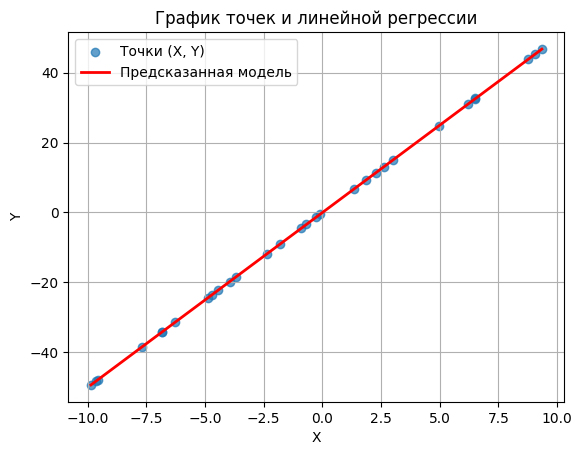

In [16]:
model.view_2d_graphic()

In [17]:
dataset = pandas.read_csv("dataset/medium_high_correlation_dataset.csv")
dataset.corr(numeric_only=True)


,A,B
A,1.000000,0.897381
B,0.897381,1.000000


In [18]:
import statsmodels.api as sm

# зависимая переменная
y = dataset["A"]

# объединяем X и Z в одну матрицу признаков
X_full = dataset["B"]

# добавляем один столбец константы
X_full = sm.add_constant(X_full)

# обучаем модель
model = sm.OLS(y, X_full).fit()
model.params

const    0.078180
B        0.297654
dtype: float64

In [19]:

model = Model()
model.add_constant(dataset["B"])
model.fit_OLS(dataset["A"], use80forEducation=True, batch_size=10, full_output=True)
model.cnt_mistakes()

C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return 

Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание


C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid

Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание


C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid

...

Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание
Мы обнаружили зацикливание


C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_MSE - self._cnt_MSE()) < epsilon:
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:182: RuntimeWarning: invalid

,Iteration,Step,norma,const,B
0,1,1.000000e-02,1.030111e+02,2.983764e-02,1.030111e+00
1,2,1.000000e-02,2.548623e+02,-3.772834e-02,-1.518512e+00
2,3,1.000000e-02,5.653723e+02,1.112460e-01,4.135211e+00
3,4,1.000000e-02,1.691863e+03,-5.654311e-02,-1.278342e+01
4,5,1.000000e-02,3.388115e+03,4.853496e-01,2.109773e+01
...,...,...,...,...,...
986,987,1.776357e-17,inf,-1.763233e+155,4.751215e+153
987,988,1.776357e-17,inf,-1.763233e+155,4.751215e+153
988,989,1.776357e-17,inf,-1.763233e+155,4.751215e+153
989,990,1.776357e-17,inf,-1.763233e+155,4.751215e+153


Расчёт параметра закончен. Был использован piecewise_constant шаг
Время выполнения: 11.057071685791016 секунд
С размером Батча: 10 строк
Использованное количество итераций: 991
const: -1.7632329650542046e+155
B: 4.751214964124651e+153
Общая использованная память: 1.23 MB
[ Top 10 потребителей памяти ]
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\IPython\core\compilerop.py:174: size=197 KiB, count=2048, average=99 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\pandas\core\internals\managers.py:363: size=129 KiB, count=1098, average=120 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3052: size=123 KiB, count=105, average=1198 B
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\tokenize.py:576: size=99.9 KiB, count=1826, average=56 B
C:\Users\k1ril\PycharmProjects\hse_hw2\hse_hw_2\.venv\Lib\site-packages\pandas\core\indexes\base.py:670: size=63.3 KiB, count=742, avera

,MSE,MAE
0,inf,1.552622e+155


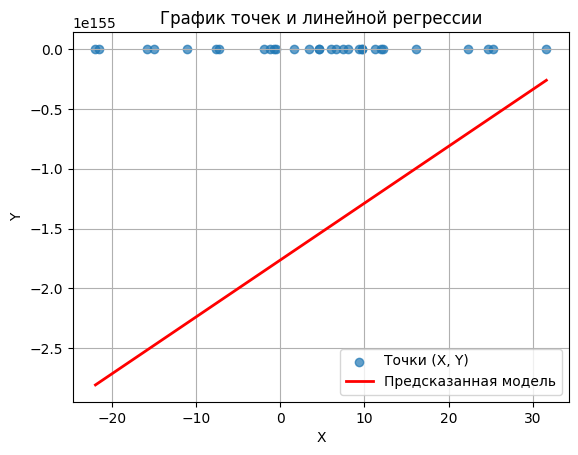

In [20]:
model.view_2d_graphic()